# Notebook 04 — Modeling: Disaster-Level (Strategic / Budget Forecasting)
**Label:** `log_total_federal_share` (log1p of total PA obligations per disaster)
**Use case:** FEMA budget planning — predict total spend before projects are filed.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
sys.path.append('../')
from utils import regression_metrics, time_based_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

PROCESSED = '../data/processed/'
disas = pd.read_csv(PROCESSED + 'cleaned_disaster_level.csv', low_memory=False)
print('Disaster-level shape:', disas.shape)
disas.head(3)


Disaster-level shape: (1766, 20)


,disasterNumber,total_federal_share,n_projects,n_counties,incidentType,stateCode,stateAbbreviation,declarationDate,incidentBeginDate,incidentEndDate,population,median_income,poverty_rate,risk_score,declaration_lag_days,incident_duration_days,incident_season,incident_year,prior_disasters_5yr,log_total_federal_share
0,1239,7950369.84,276,6,Severe Storm(s),48,TX,1998-08-26 00:00:00+00:00,1998-08-22 00:00:00+00:00,1998-08-31 00:00:00+00:00,48941150.0,46147.0,20.3,76.081425,4,9,Summer,1998,0,15.888729
1,1268,683362.94,9,2,Severe Ice Storm,56,WY,1999-02-17 00:00:00+00:00,1998-10-05 00:00:00+00:00,1998-10-09 00:00:00+00:00,200966.0,66910.0,9.9,76.685751,135,4,Fall,1998,0,13.434783
2,1257,32229051.37,1760,38,Flood,48,TX,1998-10-21 00:00:00+00:00,1998-10-17 00:00:00+00:00,1998-11-15 00:00:00+00:00,788095965.0,57157.0,14.1,86.482188,4,29,Fall,1998,1,17.288379


## 4.1 Define Features & Target


In [10]:
CAT_FEATURES = ['incidentType', 'stateAbbreviation', 'incident_season']
NUM_FEATURES = [
    'declaration_lag_days',
    'incident_duration_days',
    'n_counties',
    'n_projects',
    'prior_disasters_5yr',
    'population',
    'median_income',
    'poverty_rate',
    'risk_score',
]
TARGET = 'log_total_federal_share'

# Filter to columns that actually exist
CAT_FEATURES = [c for c in CAT_FEATURES if c in disas.columns]
NUM_FEATURES = [c for c in NUM_FEATURES if c in disas.columns]
FEATURES     = CAT_FEATURES + NUM_FEATURES

df_model = disas[FEATURES + [TARGET, 'incident_year']].dropna(subset=[TARGET])
print(f'Modeling rows: {len(df_model):,}  |  Features: {len(FEATURES)}')
print('Categorical:', CAT_FEATURES)
print('Numeric:    ', NUM_FEATURES)


Modeling rows: 1,766  |  Features: 12
Categorical: ['incidentType', 'stateAbbreviation', 'incident_season']
Numeric:     ['declaration_lag_days', 'incident_duration_days', 'n_counties', 'n_projects', 'prior_disasters_5yr', 'population', 'median_income', 'poverty_rate', 'risk_score']


## 4.2 Time-Based Train / Test Split
Train on disasters before 2018, test on 2018 onwards.
**Never use random split** on time-series data — it leaks future information into training.


In [11]:
SPLIT_YEAR = 2018
train = df_model[df_model['incident_year'] <  SPLIT_YEAR]
test  = df_model[df_model['incident_year'] >= SPLIT_YEAR]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Train years: {train["incident_year"].min()} – {train["incident_year"].max()}')
print(f'Test  years: {test["incident_year"].min()}  – {test["incident_year"].max()}')


Train: 1,202  |  Test: 564
Train years: 1998 – 2017
Test  years: 2018  – 2026


## 4.3 Preprocessing Pipeline


In [12]:
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])
preprocessor = ColumnTransformer([
    ('cat', cat_pipe, CAT_FEATURES),
    ('num', num_pipe, NUM_FEATURES)
])
print('Preprocessor defined.')


Preprocessor defined.


## 4.4 Train & Evaluate All Models


In [13]:
models = {
    'Baseline (Mean)':  DummyRegressor(strategy='mean'),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest':    RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
}

results_disaster = {}
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    m = regression_metrics(y_test.values, preds, label=name)
    m['pipeline'] = pipe
    m['preds']    = preds
    results_disaster[name] = m



  Baseline (Mean)
  MAE  :     1.9019
  RMSE :     2.4879
  R²   :    -0.0512
  MAPE :     11.79%

  Ridge Regression
  MAE  :     1.7880
  RMSE :     2.3627
  R²   :     0.0519
  MAPE :     10.86%

  Random Forest
  MAE  :     1.3660
  RMSE :     1.7262
  R²   :     0.4939
  MAPE :      7.94%


## 4.5 Results Summary Table


In [14]:
summary = pd.DataFrame([
    {k: v for k, v in v.items() if k not in ('pipeline', 'preds')}
    for v in results_disaster.values()
]).set_index('label')
summary


,MAE,RMSE,R2,MAPE
label,,,,
Baseline (Mean),1.901912,2.487898,-0.051224,11.794109
Ridge Regression,1.788030,2.362718,0.051900,10.858693
Random Forest,1.365988,1.726216,0.493919,7.941926


## 4.6 Feature Importances — Random Forest


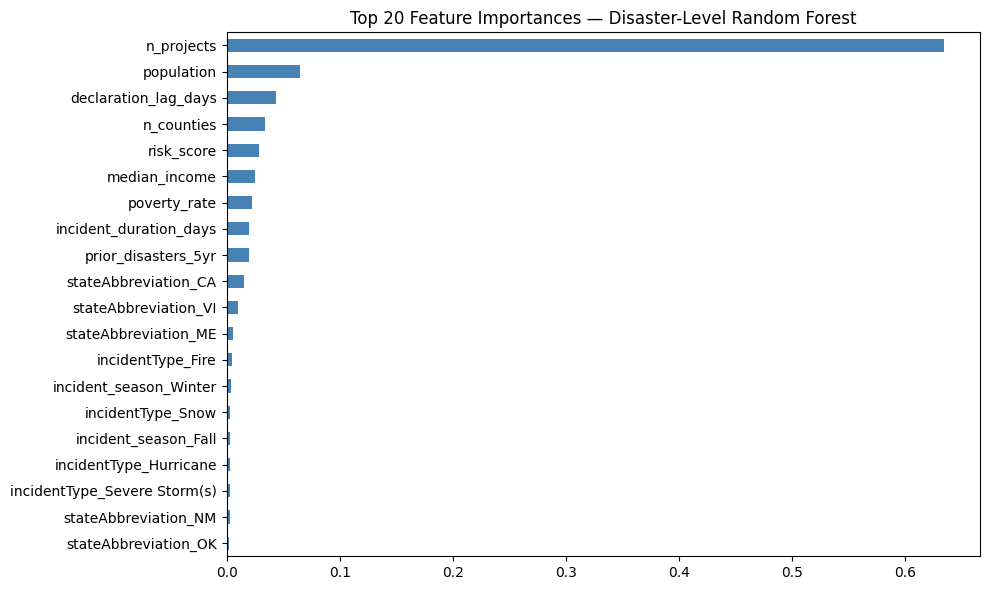

In [15]:
rf_pipe  = results_disaster['Random Forest']['pipeline']
rf_model = rf_pipe.named_steps['model']
rf_pre   = rf_pipe.named_steps['pre']

ohe_names = rf_pre.transformers_[0][1].named_steps['ohe'].get_feature_names_out(CAT_FEATURES)
all_names = list(ohe_names) + NUM_FEATURES

importances = pd.Series(rf_model.feature_importances_, index=all_names)
importances.nlargest(20).sort_values().plot(
    kind='barh', figsize=(10, 6),
    title='Top 20 Feature Importances — Disaster-Level Random Forest',
    color='steelblue'
)
plt.tight_layout()
plt.savefig('../data/processed/feature_importance_disaster.png', dpi=150)
plt.show()


## 4.7 Save Best Pipeline


In [16]:
best_name = max(results_disaster, key=lambda k: results_disaster[k]['R2'])
print(f'Best model: {best_name}  (R² = {results_disaster[best_name]["R2"]:.4f})')

with open(PROCESSED + 'best_disaster_model.pkl', 'wb') as f:
    pickle.dump({
        'pipeline':    results_disaster[best_name]['pipeline'],
        'X_test':      X_test,
        'y_test':      y_test,
        'preds':       results_disaster[best_name]['preds'],
        'features':    FEATURES,
        'cat_features': CAT_FEATURES,
        'num_features': NUM_FEATURES,
        'model_name':  best_name,
    }, f)
print('Saved best_disaster_model.pkl')


Best model: Random Forest  (R² = 0.4939)
Saved best_disaster_model.pkl
